# 💳 Dataset 3: Credit Card Fraud Detection
## Kỹ thuật: RobustScaler + Precision-Recall Optimization + PCA Visualization

**Pipeline:** EDA → Phân tích Anomaly → Scaling → Training → PR-AUC Evaluation

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (precision_recall_curve, auc, roc_auc_score,
                             confusion_matrix, classification_report, average_precision_score)
import warnings, os

import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})
sns.set_theme(style='whitegrid')

SAVE_DIR = '../results/credit_fraud'
os.makedirs(SAVE_DIR, exist_ok=True)
DATA_PATH = '../data/credit_card_fraud/creditcard.csv'
print('✅ Libraries loaded')

✅ Libraries loaded


## 📂 1. Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Fraud rate: {df["Class"].mean()*100:.4f}% ({df["Class"].sum()} frauds / {len(df)} total)')
df.head(3)

Shape: (284807, 31)
Fraud rate: 0.1727% (492 frauds / 284807 total)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


## 📊 2. EDA — Phân tích Dữ liệu Gian lận

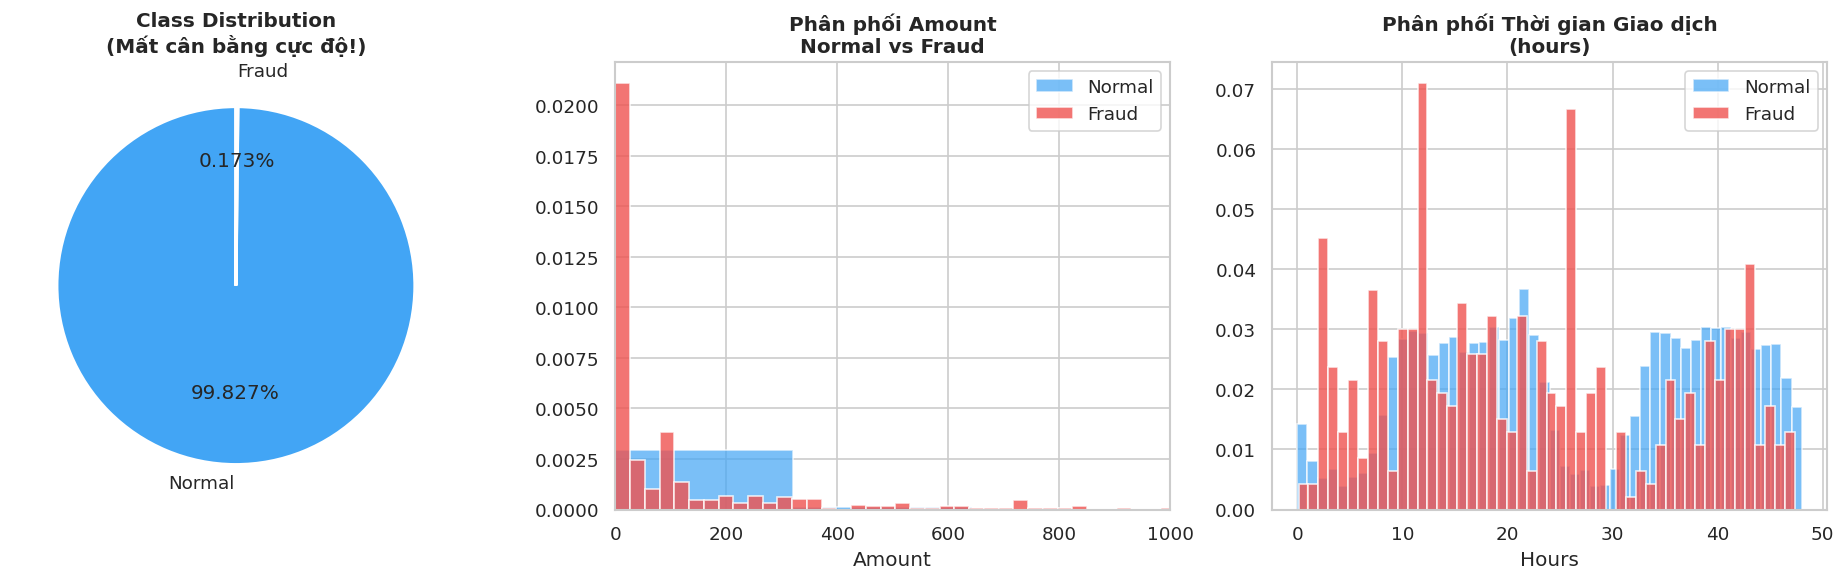

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Class imbalance
counts = df['Class'].value_counts()
axes[0].pie(counts, labels=['Normal', 'Fraud'],
            autopct='%1.3f%%', colors=['#42A5F5', '#EF5350'],
            explode=(0, 0.1), startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Class Distribution\n(Mất cân bằng cực độ!)')

# Amount distribution
axes[1].hist(df[df['Class']==0]['Amount'], bins=80, alpha=0.7, color='#42A5F5', label='Normal', density=True)
axes[1].hist(df[df['Class']==1]['Amount'], bins=80, alpha=0.8, color='#EF5350', label='Fraud', density=True)
axes[1].set_title('Phân phối Amount\nNormal vs Fraud')
axes[1].set_xlabel('Amount')
axes[1].legend()
axes[1].set_xlim(0, 1000)

# Time distribution
axes[2].hist(df[df['Class']==0]['Time']/3600, bins=50, alpha=0.7, color='#42A5F5', label='Normal', density=True)
axes[2].hist(df[df['Class']==1]['Time']/3600, bins=50, alpha=0.8, color='#EF5350', label='Fraud', density=True)
axes[2].set_title('Phân phối Thời gian Giao dịch\n(hours)')
axes[2].set_xlabel('Hours')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_class_amount_time.png', bbox_inches='tight')
plt.show()

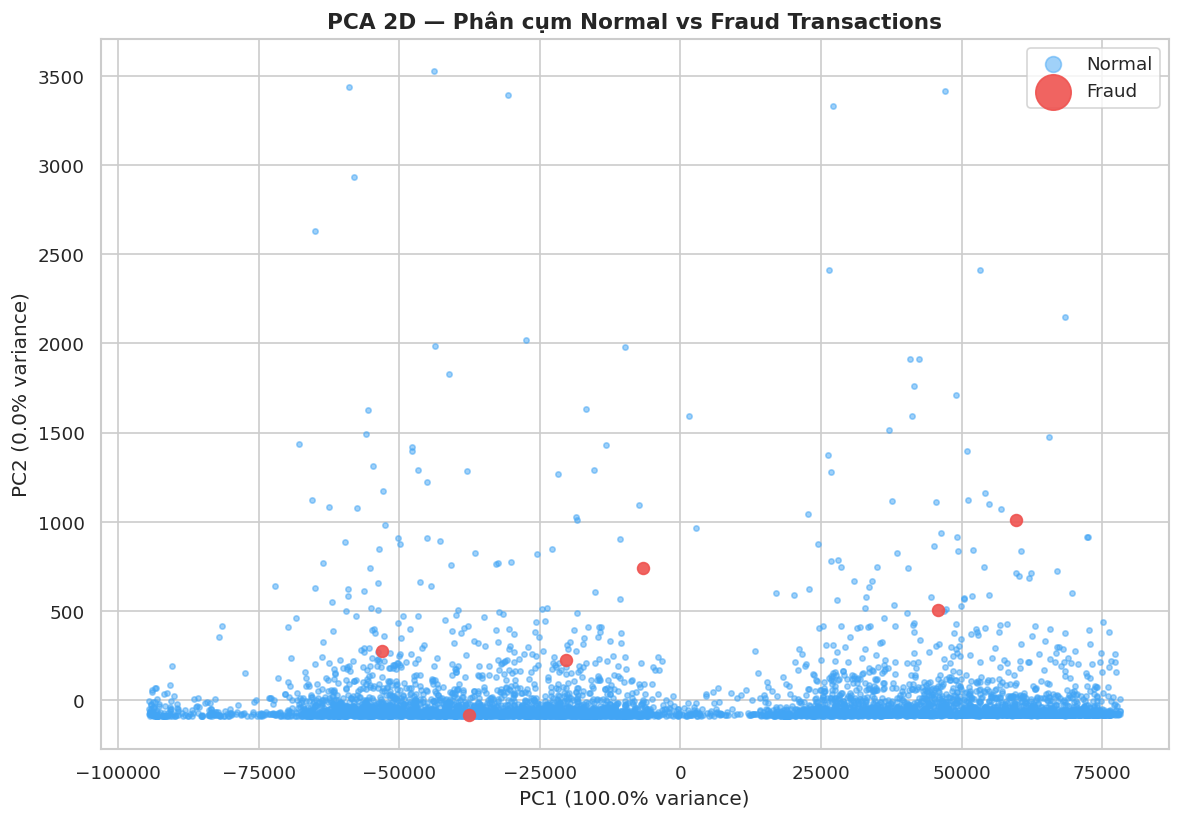

In [4]:
# PCA 2D visualization
sample = df.sample(5000, random_state=SEED)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(sample.drop('Class', axis=1))

fig, ax = plt.subplots(figsize=(10, 7))
for cls, label, color in [(0, 'Normal', '#42A5F5'), (1, 'Fraud', '#EF5350')]:
    mask = sample['Class'] == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=label, alpha=0.5 if cls==0 else 0.9,
               s=10 if cls==0 else 50, zorder=cls+1)

ax.set_title('PCA 2D — Phân cụm Normal vs Fraud Transactions', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_pca_2d_clusters.png', bbox_inches='tight')
plt.show()

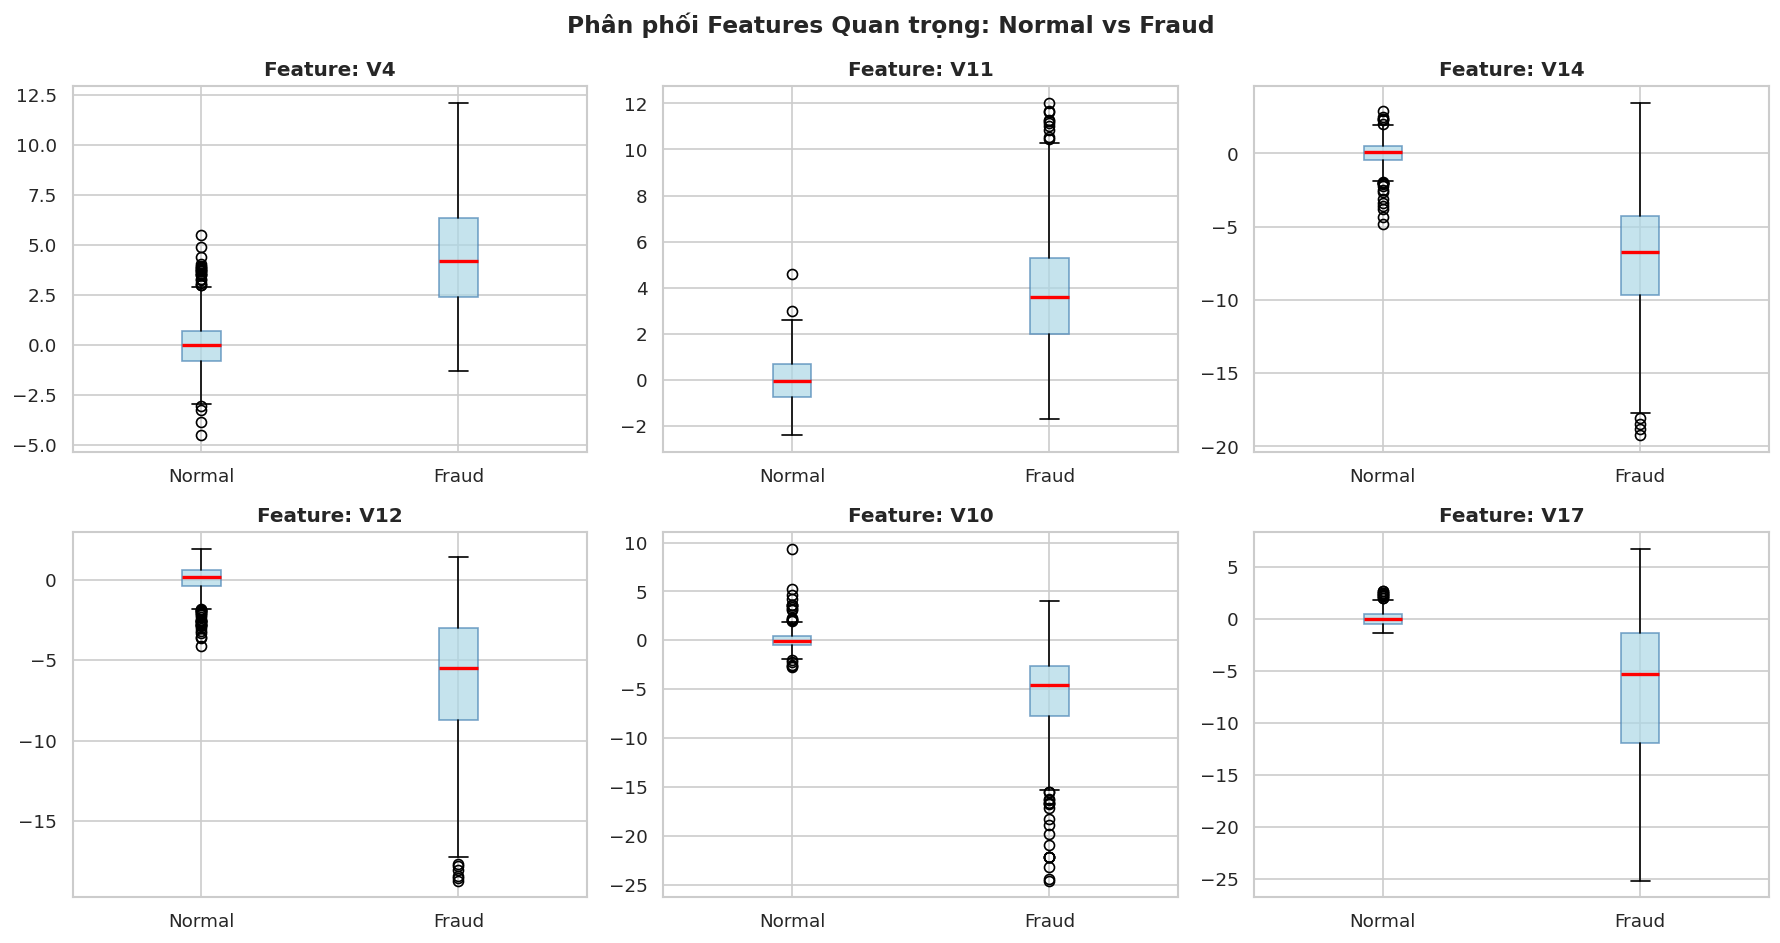

In [5]:
# Top V features boxplot (Fraud vs Normal)
top_features = ['V4', 'V11', 'V14', 'V12', 'V10', 'V17']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    data_normal = df[df['Class']==0][feat].sample(500, random_state=SEED)
    data_fraud  = df[df['Class']==1][feat]
    axes[i].boxplot([data_normal, data_fraud],
                    labels=['Normal', 'Fraud'],
                    boxprops=dict(
                        color='steelblue',
                        facecolor='lightblue',
                        alpha=0.7
                    ),
                    medianprops=dict(color='red', linewidth=2),
                    patch_artist=True)
    axes[i].set_title(f'Feature: {feat}')

plt.suptitle('Phân phối Features Quan trọng: Normal vs Fraud', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_feature_boxplots.png', bbox_inches='tight')
plt.show()

## ⚙️ 3. Preprocessing

In [6]:
df_proc = df.copy()
rob = RobustScaler()
df_proc['scaled_amount'] = rob.fit_transform(df_proc['Amount'].values.reshape(-1,1))
df_proc['scaled_time']   = rob.fit_transform(df_proc['Time'].values.reshape(-1,1))
df_proc.drop(['Amount', 'Time'], axis=1, inplace=True)

X = df_proc.drop('Class', axis=1)
y = df_proc['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f'Train: {X_train.shape}, Fraud in test: {y_test.sum()}')

Train: (227845, 30), Fraud in test: 98


## 🤖 4. Training & Precision-Recall Evaluation

In [7]:
models = {
    'Logistic Reg (Balanced)': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Random Forest (Balanced)': RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                                        random_state=SEED, n_jobs=-1)
}

results = {}
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    preds = mdl.predict(X_test)
    proba = mdl.predict_proba(X_test)[:, 1]
    pr_auc = average_precision_score(y_test, proba)
    roc_auc = roc_auc_score(y_test, proba)
    results[name] = {'preds': preds, 'proba': proba, 'PR-AUC': pr_auc, 'ROC-AUC': roc_auc}
    print(f'{name:35s} | PR-AUC={pr_auc:.4f} | ROC-AUC={roc_auc:.4f}')

Logistic Reg (Balanced)             | PR-AUC=0.7189 | ROC-AUC=0.9720


Random Forest (Balanced)            | PR-AUC=0.8653 | ROC-AUC=0.9581


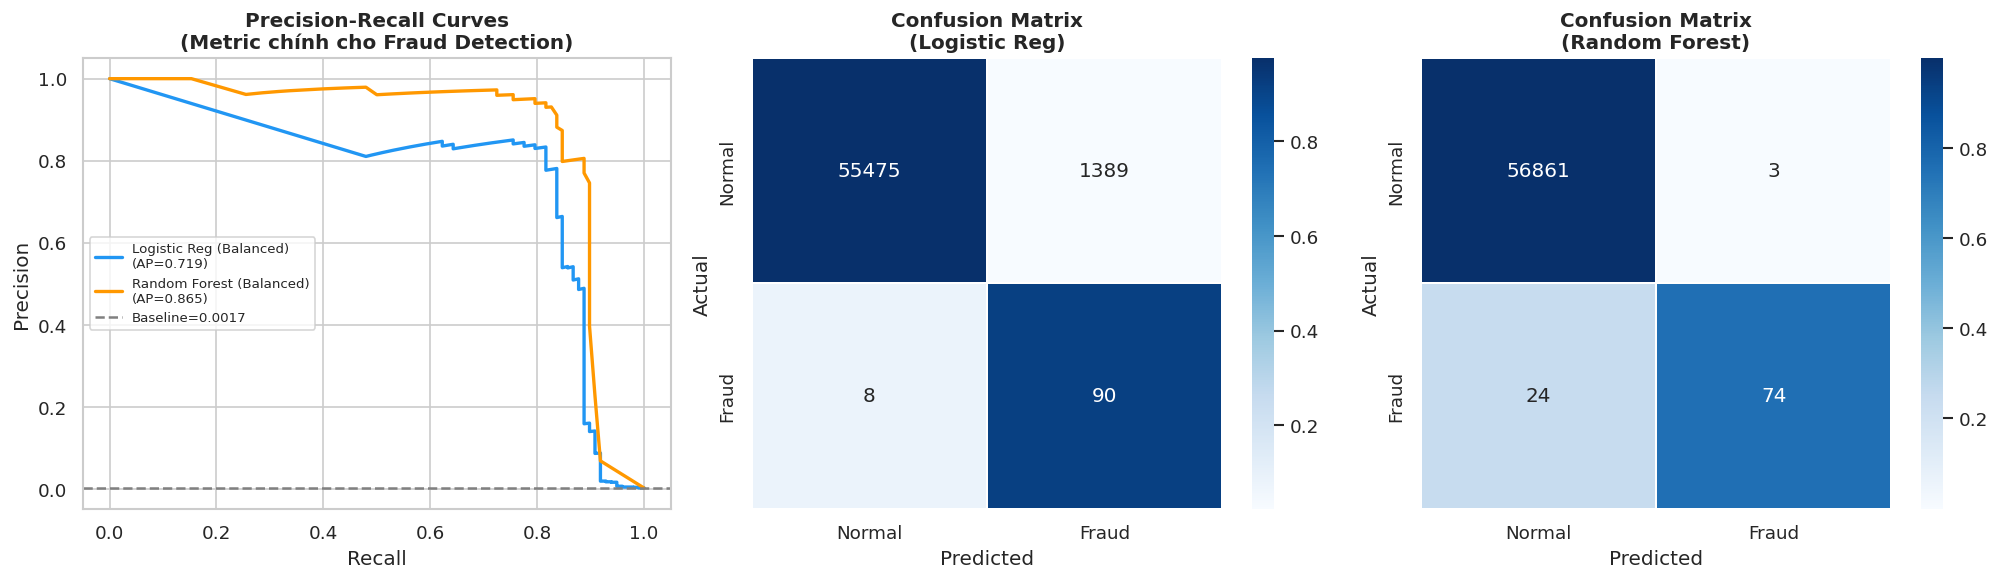

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Precision-Recall curves
colors = ['#2196F3', '#FF9800']
for (name, res), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, res['proba'])
    axes[0].plot(rec, prec, lw=2, color=color, label=f'{name}\n(AP={res["PR-AUC"]:.3f})')

baseline = y_test.mean()
axes[0].axhline(baseline, linestyle='--', color='gray', label=f'Baseline={baseline:.4f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curves\n(Metric chính cho Fraud Detection)')
axes[0].legend(fontsize=8)

# Confusion Matrices
for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', ax=axes[i+1],
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'],
                linewidths=1)
    axes[i+1].set_title(f'Confusion Matrix\n({name.split(" ")[0]} {name.split(" ")[1]})')
    axes[i+1].set_ylabel('Actual')
    axes[i+1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_pr_curve_confusion.png', bbox_inches='tight')
plt.show()

In [9]:
best_name = max(results, key=lambda m: results[m]['PR-AUC'])
print(f'Best: {best_name}')
print(classification_report(y_test, results[best_name]['preds'], target_names=['Normal', 'Fraud']))

with open(f'{SAVE_DIR}/report.txt', 'w') as f:
    f.write('Credit Card Fraud Detection Report\n' + '='*50 + '\n')
    for name, res in results.items():
        f.write(f'\n[{name}]\n')
        f.write(f'  PR-AUC  : {res["PR-AUC"]:.4f}\n')
        f.write(f'  ROC-AUC : {res["ROC-AUC"]:.4f}\n')
        f.write(classification_report(y_test, res['preds'], target_names=['Normal','Fraud']))

print('✅ Credit Fraud Experiment Completed! Results saved to', SAVE_DIR)

Best: Random Forest (Balanced)
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

✅ Credit Fraud Experiment Completed! Results saved to ../results/credit_fraud
